# XRAY HQCNN BASELINE SOBRE CNNB

# 0) IMPORTS

In [1]:
import os
import time
import math
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder

import pennylane as qml

from sklearn.metrics import (
    roc_curve, roc_auc_score, average_precision_score,
    precision_recall_curve, accuracy_score, f1_score,
    confusion_matrix, classification_report, precision_score
)

# 1) CONFIGURACIÓN GLOBAL

In [2]:
SEED = 44
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float32)

print("Using device:", DEVICE)
print("Torch default dtype:", torch.get_default_dtype())

Using device: cuda:0
Torch default dtype: torch.float32


# 2) HIPERPARÁMETROS Y RUTA DEL DATASET

In [3]:
IMG_SIZE = 256
BATCH_SIZE = 4

NUM_WORKERS = 0

FRAC_TRAIN = 0.80
FRAC_VAL = 0.10

EPOCHS = 20
LR_CL = 1e-3
LR_Q  = 3e-4
WEIGHT_DECAY = 1e-5
DROPOUT_P = 0.20

QUBITS = 4
LAYERS = 2
SHOTS = None
DIFF_METHOD = "backprop"
CHUNK_PATCHES = 2048

DATA_ROOT = r"C:\Users\lapic\datasets\Curated_XRay_256x256"

if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(
        f"No encontré la carpeta del dataset en:\n{DATA_ROOT}\n\n"
        "Verifica que la ruta exista y que contenga subcarpetas de clases, por ejemplo:\n"
        "  COVID-19/\n"
        "  Normal/\n"
        "  Pneumonia-Bacterial/\n"
        "  Pneumonia-Viral/"
    )

print(f"[Config] DATA_ROOT = {DATA_ROOT}")
print(f"[Config] IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE} | LR_CL={LR_CL} | LR_Q={LR_Q}")
print(f"[Config] QUBITS={QUBITS} | LAYERS={LAYERS} | CHUNK_PATCHES={CHUNK_PATCHES}")

[Config] DATA_ROOT = C:\Users\lapic\datasets\Curated_XRay_256x256
[Config] IMG_SIZE=256 | BATCH=4 | LR_CL=0.001 | LR_Q=0.0003
[Config] QUBITS=4 | LAYERS=2 | CHUNK_PATCHES=2048


# 3) TRANSFORMACIONES

In [4]:
tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# 4) DATASET Y FILTRO COVID/NORMAL

In [5]:
full_ds = ImageFolder(DATA_ROOT, transform=tf)
print("[Info] Clases detectadas:", full_ds.classes)
print("[Info] class_to_idx:", full_ds.class_to_idx)

def _find_class_idx(classes, keyword):
    kw = keyword.lower()
    for i, c in enumerate(classes):
        if kw in c.lower():
            return i
    return None

pos_old = _find_class_idx(full_ds.classes, "covid")
neg_old = _find_class_idx(full_ds.classes, "normal")

if pos_old is None or neg_old is None:
    raise ValueError(
        f"No detecté 'covid' y/o 'normal'. Clases encontradas: {full_ds.classes}"
    )

POS_NAME = full_ds.classes[pos_old]
NEG_NAME = full_ds.classes[neg_old]

print(f"[Info] Clase positiva = {POS_NAME} (old idx={pos_old})")
print(f"[Info] Clase negativa = {NEG_NAME} (old idx={neg_old})")

abs_indices = []
bin_targets = []

for abs_i, (_, old_y) in enumerate(full_ds.samples):
    if old_y == neg_old:
        abs_indices.append(abs_i)
        bin_targets.append(0.0)
    elif old_y == pos_old:
        abs_indices.append(abs_i)
        bin_targets.append(1.0)

abs_indices = np.asarray(abs_indices, dtype=np.int64)
bin_targets = np.asarray(bin_targets, dtype=np.float32)

print(f"[Info] Total binarias (COVID/Normal): {len(abs_indices)}")
print(f"[Info] #Normal = {(bin_targets == 0).sum()} | #COVID = {(bin_targets == 1).sum()}")

[Info] Clases detectadas: ['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
[Info] class_to_idx: {'COVID-19': 0, 'Normal': 1, 'Pneumonia-Bacterial': 2, 'Pneumonia-Viral': 3}
[Info] Clase positiva = COVID-19 (old idx=0)
[Info] Clase negativa = Normal (old idx=1)
[Info] Total binarias (COVID/Normal): 4552
[Info] #Normal = 3271 | #COVID = 1281


# 4.5) DATASET BINARIO REMAPEADO

In [6]:
class BinarySubset(Dataset):
    def __init__(self, base_dataset, abs_indices, targets):
        self.base_dataset = base_dataset
        self.abs_indices = np.asarray(abs_indices, dtype=np.int64)
        self.targets = np.asarray(targets, dtype=np.float32)

        assert len(self.abs_indices) == len(self.targets), \
            "abs_indices y targets deben tener la misma longitud"

    def __len__(self):
        return len(self.abs_indices)

    def __getitem__(self, i):
        x, _ = self.base_dataset[self.abs_indices[i]]
        y = torch.tensor(self.targets[i], dtype=torch.float32)
        return x, y

# 5) SPLIT ESTRATIFICADO

In [7]:
rng = np.random.default_rng(SEED)

idx0 = np.where(bin_targets == 0)[0]
idx1 = np.where(bin_targets == 1)[0]

rng.shuffle(idx0)
rng.shuffle(idx1)

def split_class(idxs, frac_train=0.8, frac_val=0.1):
    n = len(idxs)
    n_tr = int(round(frac_train * n))
    n_va = int(round(frac_val * n))
    tr = idxs[:n_tr]
    va = idxs[n_tr:n_tr+n_va]
    te = idxs[n_tr+n_va:]
    return tr, va, te

tr0, va0, te0 = split_class(idx0, FRAC_TRAIN, FRAC_VAL)
tr1, va1, te1 = split_class(idx1, FRAC_TRAIN, FRAC_VAL)

tr_idx = np.concatenate([tr0, tr1]); rng.shuffle(tr_idx)
va_idx = np.concatenate([va0, va1]); rng.shuffle(va_idx)
te_idx = np.concatenate([te0, te1]); rng.shuffle(te_idx)

train_abs = abs_indices[tr_idx]
val_abs   = abs_indices[va_idx]
test_abs  = abs_indices[te_idx]

train_targets = bin_targets[tr_idx]
val_targets   = bin_targets[va_idx]
test_targets  = bin_targets[te_idx]

print(f"[Split] Train={len(train_abs)} | Val={len(val_abs)} | Test={len(test_abs)}")
print(f"[Split] Train Normal/COVID = {(train_targets==0).sum()}/{(train_targets==1).sum()}")
print(f"[Split] Val   Normal/COVID = {(val_targets==0).sum()}/{(val_targets==1).sum()}")
print(f"[Split] Test  Normal/COVID = {(test_targets==0).sum()}/{(test_targets==1).sum()}")

train_ds = BinarySubset(full_ds, train_abs, train_targets)
val_ds   = BinarySubset(full_ds, val_abs, val_targets)
test_ds  = BinarySubset(full_ds, test_abs, test_targets)

[Split] Train=3642 | Val=455 | Test=455
[Split] Train Normal/COVID = 2617/1025
[Split] Val   Normal/COVID = 327/128
[Split] Test  Normal/COVID = 327/128


# 6) DATALOADERS

In [8]:
g_cpu = torch.Generator(device="cpu")
g_cpu.manual_seed(SEED)

loader_kwargs_train = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_cpu,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

loader_kwargs_eval = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

if NUM_WORKERS > 0:
    loader_kwargs_train["persistent_workers"] = True
    loader_kwargs_eval["persistent_workers"] = True

train_loader = DataLoader(train_ds, **loader_kwargs_train)
val_loader   = DataLoader(val_ds, **loader_kwargs_eval)
test_loader  = DataLoader(test_ds, **loader_kwargs_eval)

xb, yb = next(iter(train_loader))
print("[Sanity] Batch x shape:", xb.shape, "| y shape:", yb.shape)

[Sanity] Batch x shape: torch.Size([4, 1, 256, 256]) | y shape: torch.Size([4])


# 7) QNODE CUÁNTICO
Construido con la misma filosofía de:
- B_Quanvolution_CNN_PneumoniaMNIST
- 02_Cuantico2

In [9]:
pl_torch_device = "cuda" if DEVICE.type == "cuda" else "cpu"

dev = qml.device(
    "default.qubit.torch",
    wires=QUBITS,
    shots=SHOTS,
    torch_device=pl_torch_device
)

@qml.qnode(dev, interface="torch", diff_method=DIFF_METHOD)
def quanv_circuit_batched(angles_b, weights):
    # angles_b: (N,4)
    for w in range(QUBITS):
        qml.RY(angles_b[:, w], wires=w)

    # Mismo ansatz sencillo y eficiente del notebook base de quanvolution
    for l in range(LAYERS):
        for w in range(QUBITS):
            qml.RY(weights[l, w, 0], wires=w)
            qml.RZ(weights[l, w, 1], wires=w)

        qml.CNOT([0, 1])
        qml.CNOT([1, 2])
        qml.CNOT([2, 3])
        qml.CNOT([3, 0])

    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2)),
        qml.expval(qml.PauliZ(3)),
    )

# 8) BLOQUE QUANVOLUCIONAL 2x2 STRIDE2

In [10]:
class Quanv2x2Stride2_1ch(nn.Module):
    """
    Quanv para imágenes grayscale:
    Input : (B,1,256,256)
    Output: (B,4,128,128)

    Filosofía:
    - parches locales 2x2
    - codificación directa a 4 qubits
    - mismo circuito compartido para todos los parches
    - 4 observables medidos
    - reconstrucción espacial
    """
    def __init__(self, chunk_patches=CHUNK_PATCHES):
        super().__init__()
        self.weights = nn.Parameter(
            0.1 * torch.randn(LAYERS, QUBITS, 2, device=DEVICE, dtype=torch.float32)
        )
        self.chunk = chunk_patches
        self._dbg_printed = False

    def forward(self, x):
        # x: (B,1,H,W)
        B, C, H, W = x.shape
        assert C == 1, "Quanv2x2Stride2_1ch espera 1 canal."
        assert H % 2 == 0 and W % 2 == 0, "H y W deben ser pares para stride=2 sin padding."

        x = x.to(dtype=torch.float32)

        # Extraigo parches 2x2 con stride=2
        patches = F.unfold(x, kernel_size=2, stride=2)      # (B, 4, H2*W2)
        patches = patches.transpose(1, 2).reshape(-1, 4)    # (B*H2*W2, 4)

        # Escalo a ángulos
        angles = torch.pi * patches

        # QNode vectorizado con chunks
        if self.chunk is None:
            m0, m1, m2, m3 = quanv_circuit_batched(angles, self.weights)
            outs = torch.stack([m0, m1, m2, m3], dim=1)
        else:
            outs_list = []
            Np = angles.shape[0]
            for s in range(0, Np, self.chunk):
                a = angles[s:s+self.chunk]
                m0, m1, m2, m3 = quanv_circuit_batched(a, self.weights)
                outs_list.append(torch.stack([m0, m1, m2, m3], dim=1))
            outs = torch.cat(outs_list, dim=0)

        H2, W2 = H // 2, W // 2
        outs = outs.view(B, H2 * W2, 4).permute(0, 2, 1).contiguous().view(B, 4, H2, W2)
        outs = outs.to(dtype=x.dtype)

        if not self._dbg_printed:
            print(f"[Quanv2x2Stride2_1ch] input={tuple(x.shape)} output={tuple(outs.shape)} chunk={self.chunk}")
            self._dbg_printed = True

        return outs

# 9) BLOQUE CLÁSICO ESPEJO DEL BLOQUE CUÁNTICO
Opción B: Conv2d(3x3) + BN + ReLU

In [11]:
class ClassicalPatchConvBNReLU2x2Stride2(nn.Module):
    """
    Espejo clásico del bloque cuántico, opción B:
    - Conv2d 3x3 con stride=2
    - BatchNorm2d
    - ReLU
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=False)
        )
        self._dbg_printed = False

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        out = self.block(x)

        if not self._dbg_printed:
            print(
                f"[ClassicalPatchConvBNReLU] Cin={self.in_channels} -> Cout={self.out_channels} | "
                f"in={tuple(x.shape)} -> out={tuple(out.shape)}"
            )
            self._dbg_printed = True

        return out

# 10) MODELO HQCNN BASELINE SOBRE CNNB
q1 -> c2/pw2 -> c3/pw3 -> c4/pw4 -> c5/pw5

In [12]:
class HQCNN_CNNB_Baseline256(nn.Module):
    def __init__(self):
        super().__init__()

        self.q1 = Quanv2x2Stride2_1ch(chunk_patches=CHUNK_PATCHES)

        self.c2  = ClassicalPatchConvBNReLU2x2Stride2(4, 16)
        self.pw2 = nn.Conv2d(16, 32, 1)

        self.c3  = ClassicalPatchConvBNReLU2x2Stride2(32, 32)
        self.pw3 = nn.Conv2d(32, 32, 1)

        self.c4  = ClassicalPatchConvBNReLU2x2Stride2(32, 32)
        self.pw4 = nn.Conv2d(32, 32, 1)

        self.c5  = ClassicalPatchConvBNReLU2x2Stride2(32, 32)
        self.pw5 = nn.Conv2d(32, 32, 1)

        self.dropout = nn.Dropout(DROPOUT_P)
        self.fc1 = nn.Linear(32, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.to(dtype=torch.float32)

        x = self.q1(x)                 # (B,4,128,128)

        x = self.c2(x)                 # (B,16,64,64)
        x = self.pw2(x)                # (B,32,64,64)
        x = F.relu(x, inplace=False)

        x = self.c3(x)                 # (B,32,32,32)
        x = self.pw3(x)                # (B,32,32,32)
        x = F.relu(x, inplace=False)

        x = self.c4(x)                 # (B,32,16,16)
        x = self.pw4(x)                # (B,32,16,16)
        x = F.relu(x, inplace=False)

        x = self.c5(x)                 # (B,32,8,8)
        x = self.pw5(x)                # (B,32,8,8)
        x = F.relu(x, inplace=False)

        x = x.mean(dim=(2, 3))         # GAP -> (B,32)
        x = self.dropout(x)
        x = F.relu(self.fc1(x), inplace=False)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# 11) CONSTRUIR MODELO Y SANITY CHECK

In [13]:
model = HQCNN_CNNB_Baseline256().to(DEVICE)

with torch.no_grad():
    xdummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE, dtype=torch.float32)
    ydummy = model(xdummy)
    print("[Sanity] Output model:", ydummy.shape)

print(model)

[Quanv2x2Stride2_1ch] input=(2, 1, 256, 256) output=(2, 4, 128, 128) chunk=2048
[ClassicalPatchConvBNReLU] Cin=4 -> Cout=16 | in=(2, 4, 128, 128) -> out=(2, 16, 64, 64)
[ClassicalPatchConvBNReLU] Cin=32 -> Cout=32 | in=(2, 32, 64, 64) -> out=(2, 32, 32, 32)
[ClassicalPatchConvBNReLU] Cin=32 -> Cout=32 | in=(2, 32, 32, 32) -> out=(2, 32, 16, 16)
[ClassicalPatchConvBNReLU] Cin=32 -> Cout=32 | in=(2, 32, 16, 16) -> out=(2, 32, 8, 8)
[Sanity] Output model: torch.Size([2, 1])
HQCNN_CNNB_Baseline256(
  (q1): Quanv2x2Stride2_1ch()
  (c2): ClassicalPatchConvBNReLU2x2Stride2(
    (block): Sequential(
      (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (pw2): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (c3): ClassicalPatchConvBNReLU2x2Stride2(
    (block): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), paddi

# 12) CONTEO DE PARÁMETROS

In [14]:
def count_parameters(model):
    total = 0
    quantum = 0
    classical = 0

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        n = p.numel()
        total += n

        if "weights" in name and "q1" in name:
            quantum += n
        else:
            classical += n

    return total, quantum, classical

total_p, quantum_p, classical_p = count_parameters(model)
print(f"Parámetros totales   : {total_p:,}")
print(f"Parámetros cuánticos : {quantum_p:,}")
print(f"Parámetros clásicos  : {classical_p:,}")

Parámetros totales   : 34,353
Parámetros cuánticos : 16
Parámetros clásicos  : 34,337


# 13) LOSS, OPTIMIZER, SCHEDULER

In [15]:
n_pos_tr = int((train_targets == 1).sum())
n_neg_tr = int((train_targets == 0).sum())
pos_weight_val = n_neg_tr / max(1, n_pos_tr)
print(f"[Info] pos_weight usado = {pos_weight_val:.3f}")

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_val], device=DEVICE, dtype=torch.float32)
)

quantum_params = []
classical_params = []

for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if "weights" in name and "q1" in name:
        quantum_params.append(p)
    else:
        classical_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": quantum_params,  "lr": LR_Q},
        {"params": classical_params, "lr": LR_CL},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

[Info] pos_weight usado = 2.553


# 14) INICIALIZACIÓN DEL BIAS FINAL

In [16]:
p_pos = float((train_targets == 1).mean())
b0 = float(np.log(p_pos / max(1e-12, (1.0 - p_pos))))

with torch.no_grad():
    nn.init.normal_(model.fc2.weight, mean=0.0, std=0.01)
    model.fc2.bias.fill_(b0)

print(f"[Init] fc2.bias <- logit(p_pos) = {b0:.4f} (p_pos={p_pos:.4f})")

[Init] fc2.bias <- logit(p_pos) = -0.9373 (p_pos=0.2814)


# 15) HELPERS DE MÉTRICAS

In [17]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def confusion_terms(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]
    return cm, tn, fp, fn, tp

def balanced_acc_from_preds(y_true, y_pred):
    _, tn, fp, fn, tp = confusion_terms(y_true, y_pred)
    tnr = tn / max(1, tn + fp)
    tpr = tp / max(1, tp + fn)
    return 0.5 * (tnr + tpr)

def best_threshold_youden(y_true, probs):
    fpr, tpr, thrs = roc_curve(y_true, probs)
    j = tpr - fpr
    idx = int(np.argmax(j))
    thr = float(thrs[idx])
    if not np.isfinite(thr):
        thr = 0.5
    thr = min(max(thr, 0.0), 1.0)
    return thr

def metrics_at_threshold(y_true, probs, thr=0.5):
    y_pred = (probs >= thr).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bacc = balanced_acc_from_preds(y_true, y_pred)

    cm, tn, fp, fn, tp = confusion_terms(y_true, y_pred)
    sensitivity = tp / max(1, tp + fn)
    specificity = tn / max(1, tn + fp)
    pred_pos_rate = y_pred.mean()

    return {
        "thr": thr,
        "acc": acc,
        "f1": f1,
        "bacc": bacc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "pred_pos_rate": pred_pos_rate,
        "cm": cm
    }

def print_metrics_block(title, res):
    print(f"\n{title}")
    print(
        f"loss={res['loss']:.4f} | auc={res['auc']:.4f} | pr_auc={res['pr_auc']:.4f}\n"
        f"@0.5  acc={res['m05']['acc']:.4f} | f1={res['m05']['f1']:.4f} | bAcc={res['m05']['bacc']:.4f} | "
        f"sens={res['m05']['sensitivity']:.4f} | spec={res['m05']['specificity']:.4f} | pred1={res['m05']['pred_pos_rate']:.4f}\n"
        f"@thr* acc={res['mth']['acc']:.4f} | f1={res['mth']['f1']:.4f} | bAcc={res['mth']['bacc']:.4f} | "
        f"sens={res['mth']['sensitivity']:.4f} | spec={res['mth']['specificity']:.4f} | pred1={res['mth']['pred_pos_rate']:.4f} | thr={res['thr']:.4f}"
    )

# 16) TRAIN / VALIDATION POR ÉPOCA


In [18]:
def train_epoch(loader):
    model.train()
    total_loss, total, total_correct = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = (logits >= 0).long()
        total_correct += (preds == yb.long()).sum().item()
        total += xb.size(0)

    return total_loss / total, total_correct / total

@torch.no_grad()
def eval_epoch(loader, expected_targets=None, tag="val"):
    model.eval()
    all_logits, all_y = [], []
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    avg_loss = total_loss / total
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)
    probs = sigmoid_np(logits)

    if expected_targets is not None:
        assert len(expected_targets) == len(y_true), \
            f"[{tag}] Esperaba {len(expected_targets)} targets, pero obtuve {len(y_true)}"
        assert np.all(expected_targets.astype(int) == y_true), \
            f"[{tag}] Los targets del loader no coinciden con expected_targets"

    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = float("nan")

    try:
        pr_auc = average_precision_score(y_true, probs)
    except Exception:
        pr_auc = float("nan")

    m05 = metrics_at_threshold(y_true, probs, thr=0.5)
    thr = best_threshold_youden(y_true, probs)
    mth = metrics_at_threshold(y_true, probs, thr=thr)

    return {
        "loss": avg_loss,
        "auc": auc,
        "pr_auc": pr_auc,
        "thr": thr,
        "m05": m05,
        "mth": mth,
        "logits": logits,
        "probs": probs,
        "y_true": y_true
    }

# 17) HELPERS DE CHECKPOINTS

In [19]:
def clone_state_dict_cpu(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

best_models = {
    "val_loss":    {"best": float("inf"),   "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_bacc_th": {"best": -float("inf"),  "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_f1_th":   {"best": -float("inf"),  "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_auc":     {"best": -float("inf"),  "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
}

def maybe_update_checkpoint(name, score, epoch, thr, val_res, mode="max"):
    current_best = best_models[name]["best"]
    improved = (score < current_best) if mode == "min" else (score > current_best)

    if improved:
        best_models[name]["best"] = float(score)
        best_models[name]["epoch"] = int(epoch)
        best_models[name]["thr"] = float(thr)
        best_models[name]["state"] = clone_state_dict_cpu(model)
        best_models[name]["val_metrics"] = copy.deepcopy(val_res)

def load_checkpoint_from_registry(name):
    pack = best_models[name]
    if pack["state"] is None:
        raise ValueError(f"No hay checkpoint guardado para {name}")
    model.load_state_dict(pack["state"])
    model.to(DEVICE)
    return pack["thr"], pack["epoch"]

# 18) LOOP PRINCIPAL + MÚLTIPLES CHECKPOINTS


In [20]:
history = {
    "tr_loss": [], "tr_acc05": [],
    "va_loss": [], "va_auc": [], "va_pr": [],
    "va_acc05": [], "va_f105": [], "va_bacc05": [], "va_pred105": [],
    "va_sens05": [], "va_spec05": [],
    "va_thr": [],
    "va_accth": [], "va_f1th": [], "va_baccth": [], "va_pred1th": [],
    "va_sensth": [], "va_specth": [],
    "lr_q": [], "lr_cl": []
}

for ep in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc05 = train_epoch(train_loader)
    val_res = eval_epoch(val_loader, expected_targets=val_targets, tag="val")

    va_loss = val_res["loss"]
    scheduler.step(va_loss)

    dt = time.time() - t0
    current_lr_q  = optimizer.param_groups[0]["lr"]
    current_lr_cl = optimizer.param_groups[1]["lr"]

    history["tr_loss"].append(tr_loss)
    history["tr_acc05"].append(tr_acc05)

    history["va_loss"].append(val_res["loss"])
    history["va_auc"].append(val_res["auc"])
    history["va_pr"].append(val_res["pr_auc"])

    history["va_acc05"].append(val_res["m05"]["acc"])
    history["va_f105"].append(val_res["m05"]["f1"])
    history["va_bacc05"].append(val_res["m05"]["bacc"])
    history["va_pred105"].append(val_res["m05"]["pred_pos_rate"])
    history["va_sens05"].append(val_res["m05"]["sensitivity"])
    history["va_spec05"].append(val_res["m05"]["specificity"])

    history["va_thr"].append(val_res["thr"])
    history["va_accth"].append(val_res["mth"]["acc"])
    history["va_f1th"].append(val_res["mth"]["f1"])
    history["va_baccth"].append(val_res["mth"]["bacc"])
    history["va_pred1th"].append(val_res["mth"]["pred_pos_rate"])
    history["va_sensth"].append(val_res["mth"]["sensitivity"])
    history["va_specth"].append(val_res["mth"]["specificity"])

    history["lr_q"].append(current_lr_q)
    history["lr_cl"].append(current_lr_cl)

    maybe_update_checkpoint("val_loss",    val_res["loss"],         ep, val_res["thr"], val_res, mode="min")
    maybe_update_checkpoint("val_bacc_th", val_res["mth"]["bacc"], ep, val_res["thr"], val_res, mode="max")
    maybe_update_checkpoint("val_f1_th",   val_res["mth"]["f1"],   ep, val_res["thr"], val_res, mode="max")
    maybe_update_checkpoint("val_auc",     val_res["auc"],         ep, val_res["thr"], val_res, mode="max")

    print(
        f"Época {ep:02d} (dt={dt:.1f}s) | "
        f"Train loss={tr_loss:.4f} acc@0.5={100*tr_acc05:.1f}% | "
        f"Val loss={val_res['loss']:.4f} AUC={val_res['auc']:.3f} PR-AUC={val_res['pr_auc']:.3f} | "
        f"@0.5 acc={100*val_res['m05']['acc']:.1f}% F1={val_res['m05']['f1']:.3f} bAcc={val_res['m05']['bacc']:.3f} pred1={100*val_res['m05']['pred_pos_rate']:.1f}% | "
        f"@thr* acc={100*val_res['mth']['acc']:.1f}% F1={val_res['mth']['f1']:.3f} bAcc={val_res['mth']['bacc']:.3f} pred1={100*val_res['mth']['pred_pos_rate']:.1f}% thr={val_res['thr']:.3f} | "
        f"LR_Q={current_lr_q:.2e} | LR_CL={current_lr_cl:.2e}"
    )

Época 01 (dt=1405.6s) | Train loss=0.6304 acc@0.5=87.0% | Val loss=0.2956 AUC=0.979 PR-AUC=0.962 | @0.5 acc=94.5% F1=0.903 bAcc=0.933 pred1=28.4% | @thr* acc=94.7% F1=0.906 bAcc=0.935 pred1=28.1% thr=0.575 | LR_Q=3.00e-04 | LR_CL=1.00e-03
Época 02 (dt=1406.0s) | Train loss=0.4825 acc@0.5=92.8% | Val loss=0.1956 AUC=0.993 PR-AUC=0.986 | @0.5 acc=95.8% F1=0.925 bAcc=0.945 pred1=27.5% | @thr* acc=95.8% F1=0.930 bAcc=0.966 pred1=31.4% thr=0.068 | LR_Q=3.00e-04 | LR_CL=1.00e-03
Época 03 (dt=1405.7s) | Train loss=0.4825 acc@0.5=93.3% | Val loss=0.3218 AUC=0.990 PR-AUC=0.975 | @0.5 acc=95.4% F1=0.914 bAcc=0.930 pred1=25.7% | @thr* acc=96.5% F1=0.938 bAcc=0.961 pred1=29.0% thr=0.039 | LR_Q=3.00e-04 | LR_CL=1.00e-03
Época 04 (dt=1409.7s) | Train loss=0.3937 acc@0.5=95.1% | Val loss=0.1239 AUC=0.996 PR-AUC=0.992 | @0.5 acc=97.6% F1=0.958 bAcc=0.981 pred1=30.1% | @thr* acc=97.6% F1=0.958 bAcc=0.981 pred1=30.1% thr=0.597 | LR_Q=3.00e-04 | LR_CL=1.00e-03
Época 05 (dt=1412.5s) | Train loss=0.3720 ac

# 19) GRÁFICAS COMPLETAS


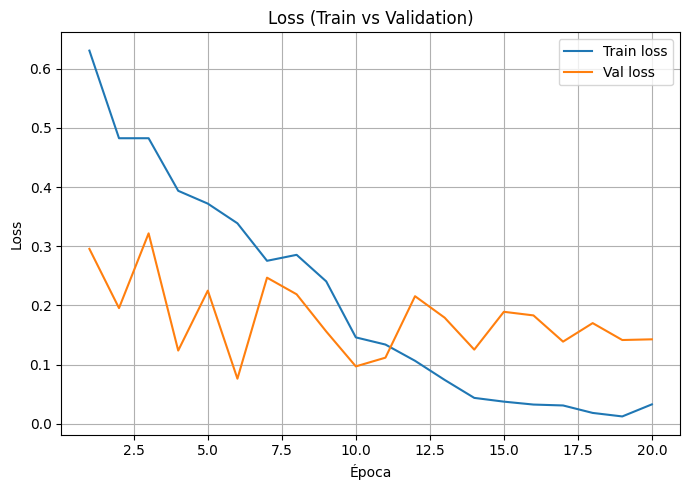

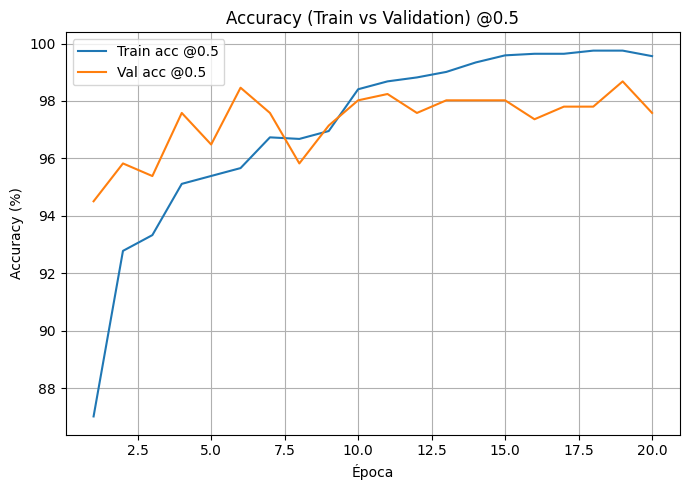

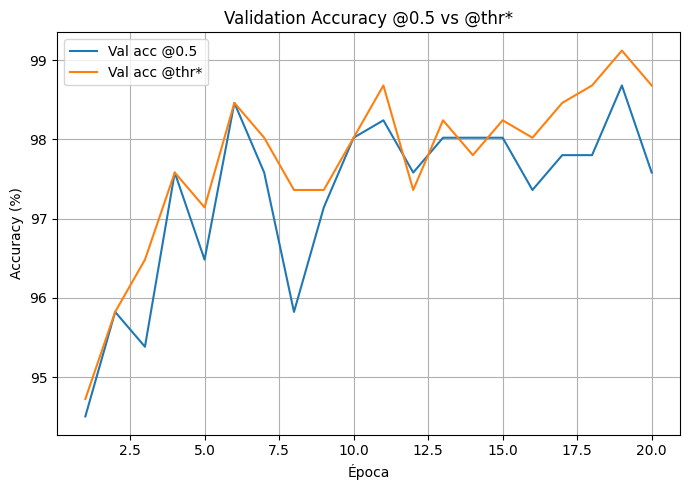

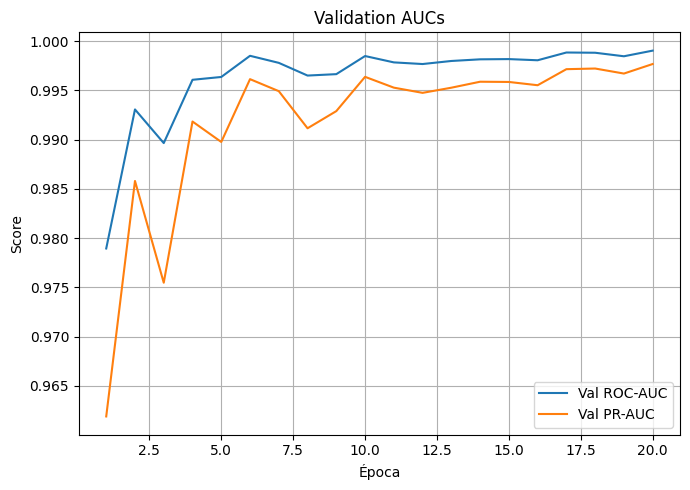

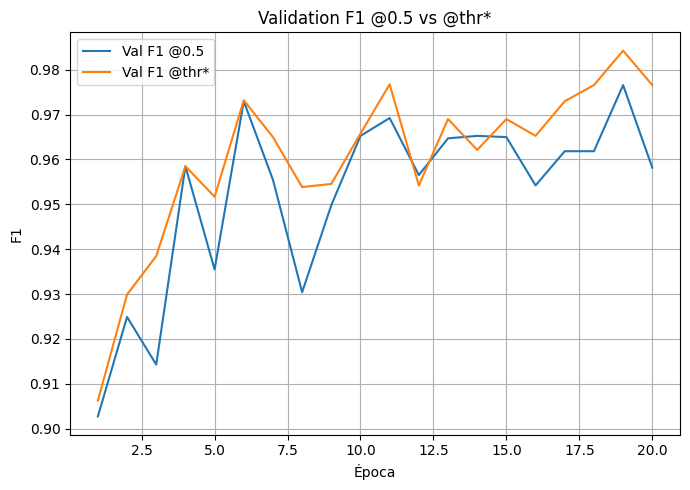

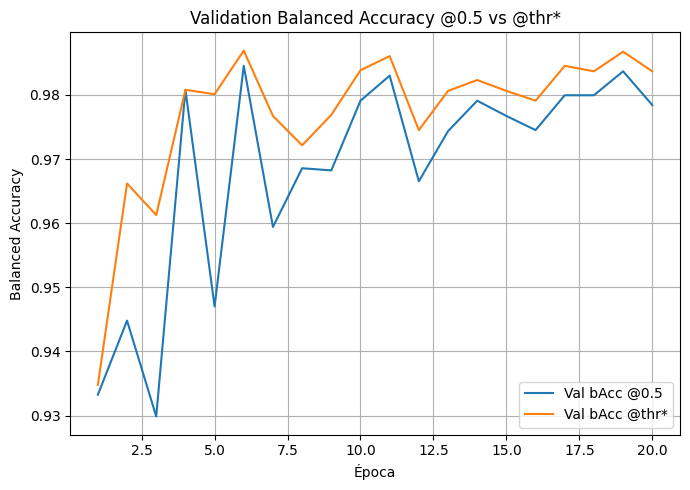

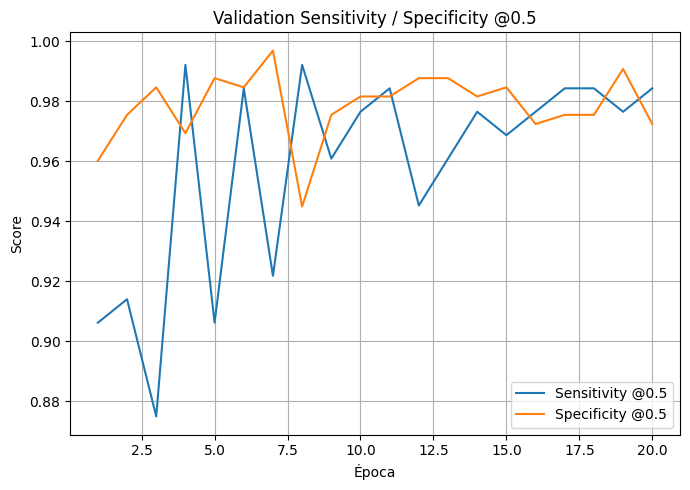

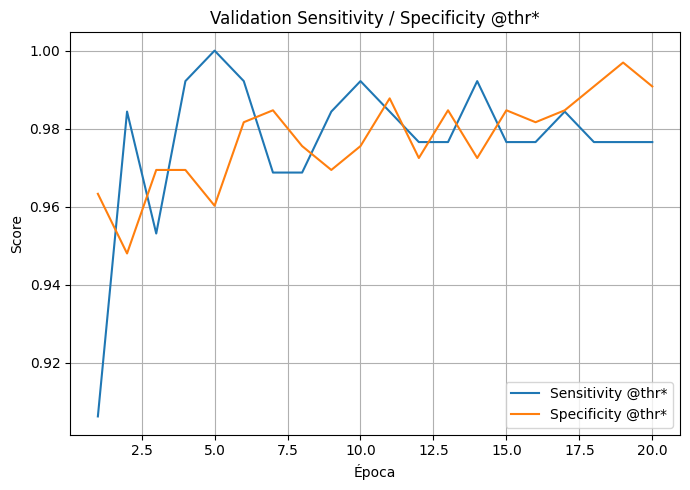

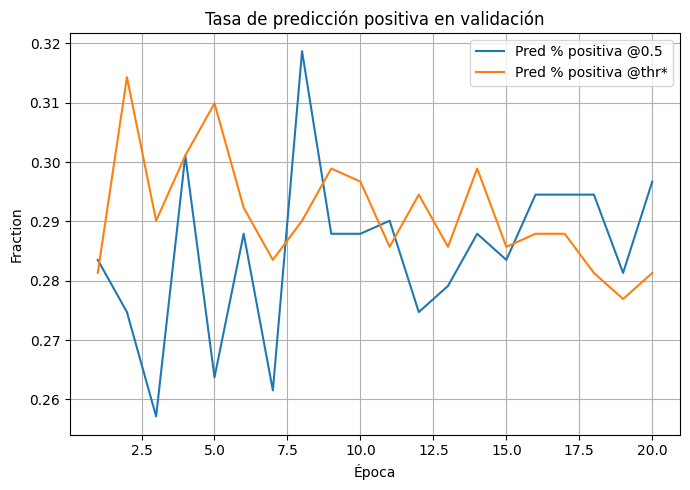

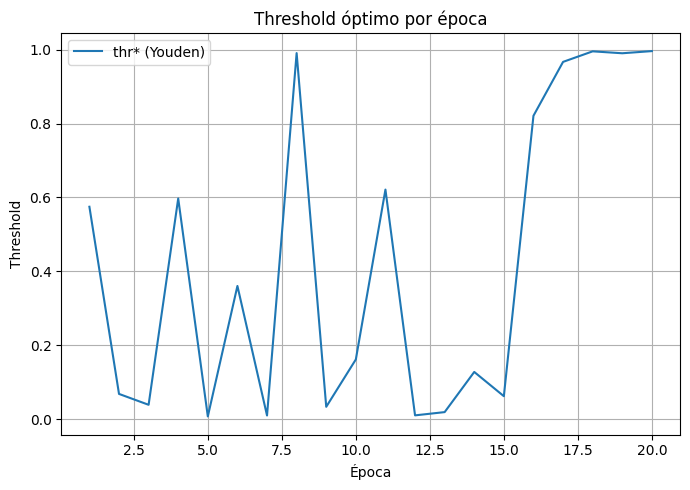

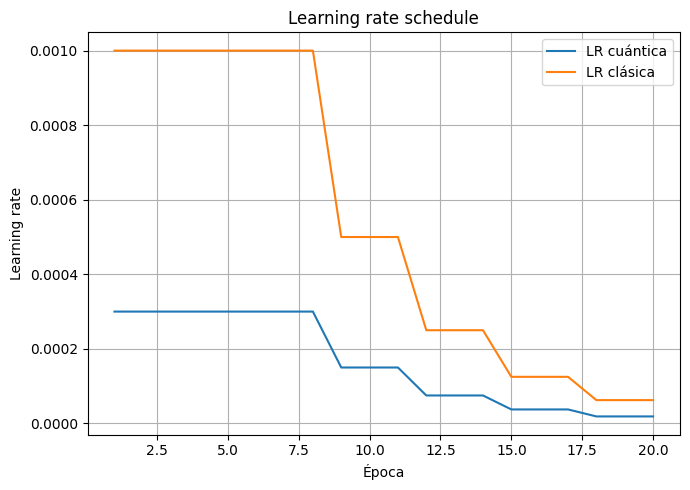

In [21]:
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, history["tr_loss"], label="Train loss")
plt.plot(epochs, history["va_loss"], label="Val loss")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.title("Loss (Train vs Validation)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, np.array(history["tr_acc05"]) * 100, label="Train acc @0.5")
plt.plot(epochs, np.array(history["va_acc05"]) * 100, label="Val acc @0.5")
plt.xlabel("Época"); plt.ylabel("Accuracy (%)")
plt.title("Accuracy (Train vs Validation) @0.5")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, np.array(history["va_acc05"]) * 100, label="Val acc @0.5")
plt.plot(epochs, np.array(history["va_accth"]) * 100, label="Val acc @thr*")
plt.xlabel("Época"); plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy @0.5 vs @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_auc"], label="Val ROC-AUC")
plt.plot(epochs, history["va_pr"], label="Val PR-AUC")
plt.xlabel("Época"); plt.ylabel("Score")
plt.title("Validation AUCs")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_f105"], label="Val F1 @0.5")
plt.plot(epochs, history["va_f1th"], label="Val F1 @thr*")
plt.xlabel("Época"); plt.ylabel("F1")
plt.title("Validation F1 @0.5 vs @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_bacc05"], label="Val bAcc @0.5")
plt.plot(epochs, history["va_baccth"], label="Val bAcc @thr*")
plt.xlabel("Época"); plt.ylabel("Balanced Accuracy")
plt.title("Validation Balanced Accuracy @0.5 vs @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_sens05"], label="Sensitivity @0.5")
plt.plot(epochs, history["va_spec05"], label="Specificity @0.5")
plt.xlabel("Época"); plt.ylabel("Score")
plt.title("Validation Sensitivity / Specificity @0.5")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_sensth"], label="Sensitivity @thr*")
plt.plot(epochs, history["va_specth"], label="Specificity @thr*")
plt.xlabel("Época"); plt.ylabel("Score")
plt.title("Validation Sensitivity / Specificity @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_pred105"], label="Pred % positiva @0.5")
plt.plot(epochs, history["va_pred1th"], label="Pred % positiva @thr*")
plt.xlabel("Época"); plt.ylabel("Fraction")
plt.title("Tasa de predicción positiva en validación")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_thr"], label="thr* (Youden)")
plt.xlabel("Época"); plt.ylabel("Threshold")
plt.title("Threshold óptimo por época")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["lr_q"], label="LR cuántica")
plt.plot(epochs, history["lr_cl"], label="LR clásica")
plt.xlabel("Época"); plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# 20) EVALUACIÓN EN TEST


In [22]:
@torch.no_grad()
def eval_test(loader, thr, expected_targets=None, tag="test"):
    model.eval()
    all_logits, all_y = [], []
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    avg_loss = total_loss / total
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)
    probs = sigmoid_np(logits)

    if expected_targets is not None:
        assert len(expected_targets) == len(y_true), \
            f"[{tag}] Esperaba {len(expected_targets)} targets, pero obtuve {len(y_true)}"
        assert np.all(expected_targets.astype(int) == y_true), \
            f"[{tag}] Los targets del loader no coinciden con expected_targets"

    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = float("nan")

    try:
        pr_auc = average_precision_score(y_true, probs)
    except Exception:
        pr_auc = float("nan")

    m = metrics_at_threshold(y_true, probs, thr=thr)

    return {
        "loss": avg_loss,
        "auc": auc,
        "pr_auc": pr_auc,
        "thr": thr,
        "acc": m["acc"],
        "f1": m["f1"],
        "bacc": m["bacc"],
        "sensitivity": m["sensitivity"],
        "specificity": m["specificity"],
        "pred_pos_rate": m["pred_pos_rate"],
        "cm": m["cm"],
        "y_true": y_true,
        "probs": probs,
        "logits": logits
    }

def print_test(title, res):
    print(f"\n{title}")
    print(
        f"loss={res['loss']:.4f} | auc={res['auc']:.4f} | pr_auc={res['pr_auc']:.4f} | "
        f"acc={res['acc']:.4f} | f1={res['f1']:.4f} | bAcc={res['bacc']:.4f} | "
        f"sens={res['sensitivity']:.4f} | spec={res['specificity']:.4f} | "
        f"pred1={res['pred_pos_rate']:.4f} | thr={res['thr']:.4f}"
    )
    print("CM:\n", res["cm"])

# 21) EVALUAR TODOS LOS MEJORES CHECKPOINTS EN TEST

In [23]:
test_results_by_ckpt = {}

for ck_name in ["val_loss", "val_bacc_th", "val_f1_th", "val_auc"]:
    thr_ck, ep_ck = load_checkpoint_from_registry(ck_name)

    res_05 = eval_test(test_loader, 0.5, expected_targets=test_targets, tag=f"{ck_name}_test05")
    res_th = eval_test(test_loader, thr_ck, expected_targets=test_targets, tag=f"{ck_name}_testthr")

    test_results_by_ckpt[ck_name] = {
        "epoch": ep_ck,
        "thr_val": thr_ck,
        "test@0.5": res_05,
        "test@thr*": res_th
    }

    print(f"\n{'='*80}")
    print(f"CHECKPOINT: {ck_name} | epoch={ep_ck} | thr_val={thr_ck:.3f}")
    print_test(f"{ck_name} -> TEST @0.5", res_05)
    print_test(f"{ck_name} -> TEST @thr*", res_th)


CHECKPOINT: val_loss | epoch=6 | thr_val=0.360

val_loss -> TEST @0.5
loss=0.1459 | auc=0.9962 | pr_auc=0.9919 | acc=0.9824 | f1=0.9688 | bAcc=0.9783 | sens=0.9688 | spec=0.9878 | pred1=0.2813 | thr=0.5000
CM:
 [[323   4]
 [  4 124]]

val_loss -> TEST @thr*
loss=0.1459 | auc=0.9962 | pr_auc=0.9919 | acc=0.9824 | f1=0.9690 | bAcc=0.9806 | sens=0.9766 | spec=0.9847 | pred1=0.2857 | thr=0.3604
CM:
 [[322   5]
 [  3 125]]

CHECKPOINT: val_bacc_th | epoch=6 | thr_val=0.360

val_bacc_th -> TEST @0.5
loss=0.1459 | auc=0.9962 | pr_auc=0.9919 | acc=0.9824 | f1=0.9688 | bAcc=0.9783 | sens=0.9688 | spec=0.9878 | pred1=0.2813 | thr=0.5000
CM:
 [[323   4]
 [  4 124]]

val_bacc_th -> TEST @thr*
loss=0.1459 | auc=0.9962 | pr_auc=0.9919 | acc=0.9824 | f1=0.9690 | bAcc=0.9806 | sens=0.9766 | spec=0.9847 | pred1=0.2857 | thr=0.3604
CM:
 [[322   5]
 [  3 125]]

CHECKPOINT: val_f1_th | epoch=19 | thr_val=0.990

val_f1_th -> TEST @0.5
loss=0.2238 | auc=0.9976 | pr_auc=0.9951 | acc=0.9824 | f1=0.9683 | bAc

# 22) ELEGIR UNO PARA GRÁFICAS FINALES

In [24]:
FINAL_CKPT_NAME = "val_bacc_th"

thr_final, ep_final = load_checkpoint_from_registry(FINAL_CKPT_NAME)
res05_final  = eval_test(test_loader, 0.5, expected_targets=test_targets, tag="final_test05")
resthr_final = eval_test(test_loader, thr_final, expected_targets=test_targets, tag="final_testthr")

print(f"\n[Info] Checkpoint final seleccionado para gráficas: {FINAL_CKPT_NAME} (epoch={ep_final}, thr={thr_final:.3f})")


[Info] Checkpoint final seleccionado para gráficas: val_bacc_th (epoch=6, thr=0.360)


# 23) ROC, PR Y BARRIDO DE THRESHOLD

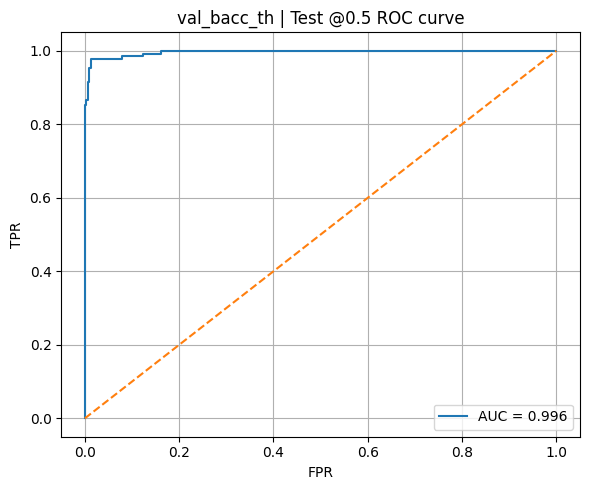

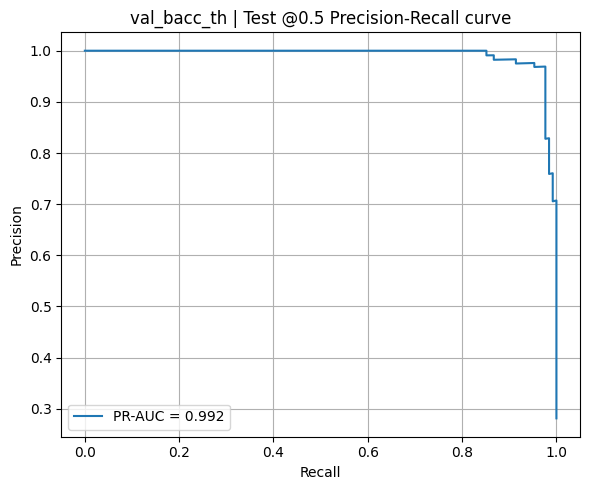

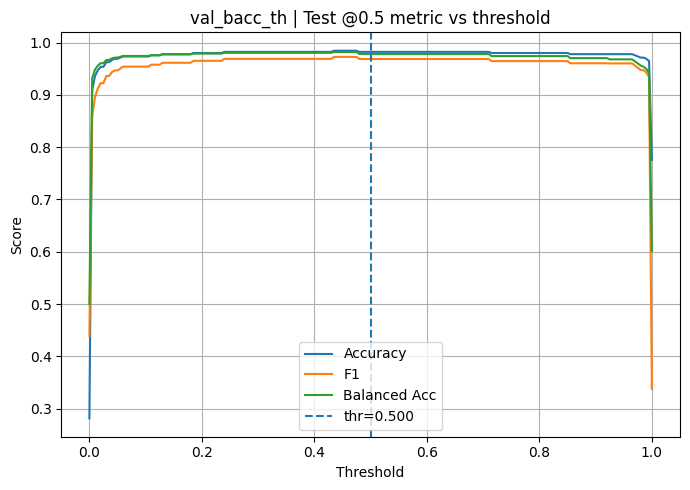

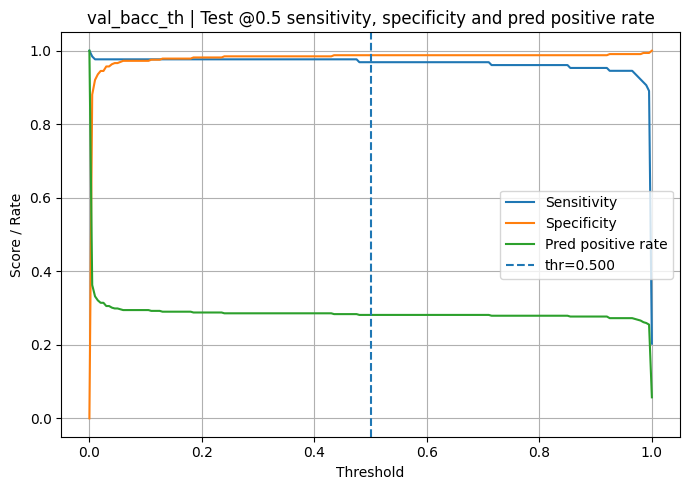

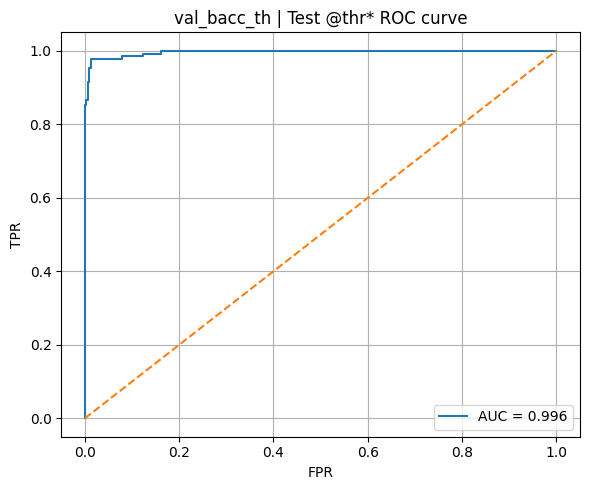

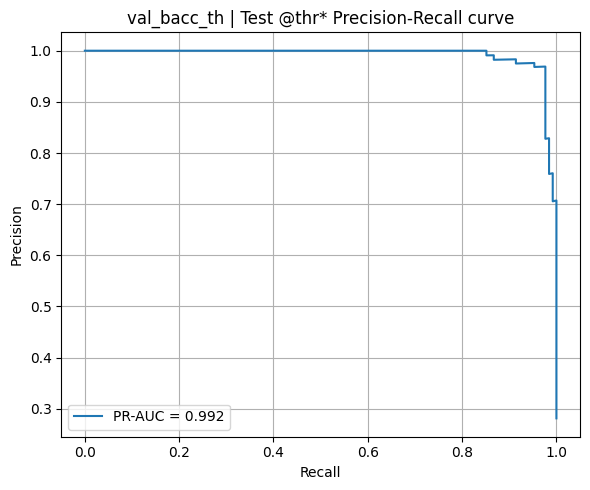

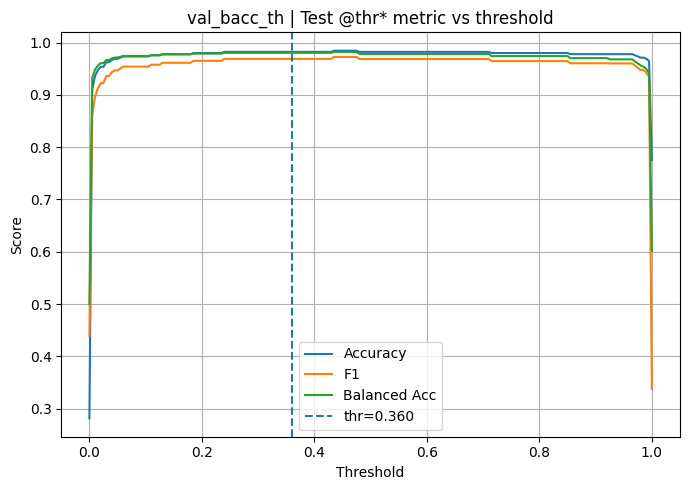

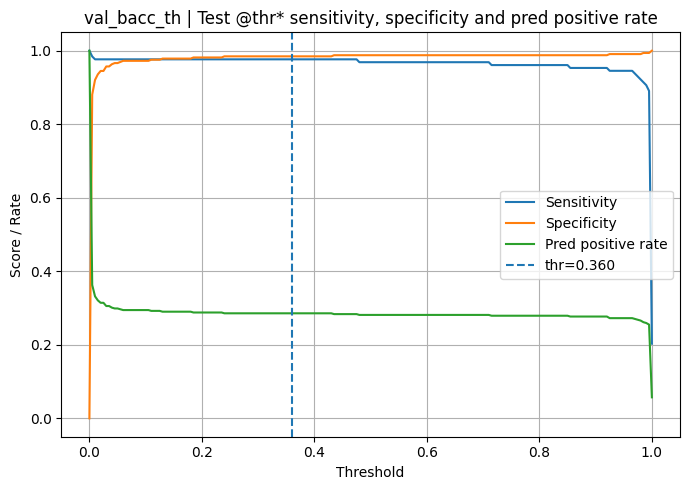

In [25]:
def plot_roc_pr_and_thresholds(res, title_prefix="Test"):
    y_true = res["y_true"]
    probs = res["probs"]

    fpr, tpr, _ = roc_curve(y_true, probs)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {res['auc']:.3f}")
    plt.plot([0,1], [0,1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} ROC curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    prec, rec, _ = precision_recall_curve(y_true, probs)
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, label=f"PR-AUC = {res['pr_auc']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision-Recall curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    thrs = np.linspace(0.0, 1.0, 201)
    accs, f1s, baccs = [], [], []
    senss, specs, p1s = [], [], []

    for thr in thrs:
        m = metrics_at_threshold(y_true, probs, thr=thr)
        accs.append(m["acc"])
        f1s.append(m["f1"])
        baccs.append(m["bacc"])
        senss.append(m["sensitivity"])
        specs.append(m["specificity"])
        p1s.append(m["pred_pos_rate"])

    plt.figure(figsize=(7,5))
    plt.plot(thrs, accs, label="Accuracy")
    plt.plot(thrs, f1s, label="F1")
    plt.plot(thrs, baccs, label="Balanced Acc")
    plt.axvline(res["thr"], linestyle="--", label=f"thr={res['thr']:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} metric vs threshold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(thrs, senss, label="Sensitivity")
    plt.plot(thrs, specs, label="Specificity")
    plt.plot(thrs, p1s, label="Pred positive rate")
    plt.axvline(res["thr"], linestyle="--", label=f"thr={res['thr']:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score / Rate")
    plt.title(f"{title_prefix} sensitivity, specificity and pred positive rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_roc_pr_and_thresholds(res05_final,  title_prefix=f"{FINAL_CKPT_NAME} | Test @0.5")
plot_roc_pr_and_thresholds(resthr_final, title_prefix=f"{FINAL_CKPT_NAME} | Test @thr*")

# 24) TABLA RESUMEN DE TODOS LOS CHECKPOINTS


In [26]:
summary_rows = []
for ck_name, pack in test_results_by_ckpt.items():
    r05 = pack["test@0.5"]
    rth = pack["test@thr*"]

    summary_rows.append({
        "checkpoint": ck_name,
        "epoch": pack["epoch"],
        "thr_val": pack["thr_val"],

        "test_acc@0.5": r05["acc"],
        "test_f1@0.5": r05["f1"],
        "test_bacc@0.5": r05["bacc"],
        "test_sens@0.5": r05["sensitivity"],
        "test_spec@0.5": r05["specificity"],
        "test_auc": r05["auc"],
        "test_pr_auc": r05["pr_auc"],

        "test_acc@thr*": rth["acc"],
        "test_f1@thr*": rth["f1"],
        "test_bacc@thr*": rth["bacc"],
        "test_sens@thr*": rth["sensitivity"],
        "test_spec@thr*": rth["specificity"],
    })

summary_df = pd.DataFrame(summary_rows)
print("\nResumen checkpoints en TEST:")
print(summary_df.sort_values(by="test_bacc@thr*", ascending=False).to_string(index=False))


Resumen checkpoints en TEST:
 checkpoint  epoch  thr_val  test_acc@0.5  test_f1@0.5  test_bacc@0.5  test_sens@0.5  test_spec@0.5  test_auc  test_pr_auc  test_acc@thr*  test_f1@thr*  test_bacc@thr*  test_sens@thr*  test_spec@thr*
   val_loss      6 0.360389      0.982418     0.968750       0.978259       0.968750       0.987768  0.996177     0.991874       0.982418      0.968992        0.980636        0.976562        0.984709
val_bacc_th      6 0.360389      0.982418     0.968750       0.978259       0.968750       0.987768  0.996177     0.991874       0.982418      0.968992        0.980636        0.976562        0.984709
    val_auc     20 0.996065      0.986813     0.976378       0.981317       0.968750       0.993884  0.997444     0.995017       0.982418      0.968000        0.971127        0.945312        0.996942
  val_f1_th     19 0.990214      0.982418     0.968254       0.973504       0.953125       0.993884  0.997563     0.995092       0.978022      0.959677        0.963315   

# 25) RESUMEN FINAL

In [27]:
print("\n" + "=" * 70)
print("RESUMEN FINAL DEL EXPERIMENTO")
print("=" * 70)
print(f"Parámetros totales       : {total_p:,}")
print(f"Parámetros cuánticos     : {quantum_p:,}")
print(f"Parámetros clásicos      : {classical_p:,}")

print("\nMejores checkpoints en validación:")
for k, v in best_models.items():
    print(f" - {k}: epoch={v['epoch']} | best={v['best']:.6f} | thr={v['thr']:.3f}")

print(f"\nCheckpoint final usado para curvas: {FINAL_CKPT_NAME}")
print(f"Epoch final: {ep_final}")
print(f"Threshold final: {thr_final:.4f}")

print("\n--- Final Test @0.5 ---")
print(
    f"loss={res05_final['loss']:.4f} | "
    f"acc={res05_final['acc']:.4f} | "
    f"f1={res05_final['f1']:.4f} | "
    f"bAcc={res05_final['bacc']:.4f} | "
    f"sens={res05_final['sensitivity']:.4f} | "
    f"spec={res05_final['specificity']:.4f} | "
    f"AUC={res05_final['auc']:.4f} | "
    f"PR-AUC={res05_final['pr_auc']:.4f}"
)

print("\n--- Final Test @thr* ---")
print(
    f"loss={resthr_final['loss']:.4f} | "
    f"acc={resthr_final['acc']:.4f} | "
    f"f1={resthr_final['f1']:.4f} | "
    f"bAcc={resthr_final['bacc']:.4f} | "
    f"sens={resthr_final['sensitivity']:.4f} | "
    f"spec={resthr_final['specificity']:.4f} | "
    f"AUC={resthr_final['auc']:.4f} | "
    f"PR-AUC={resthr_final['pr_auc']:.4f}"
)

print("\nCM final @0.5:\n", res05_final["cm"])
print("\nCM final @thr*:\n", resthr_final["cm"])


RESUMEN FINAL DEL EXPERIMENTO
Parámetros totales       : 34,353
Parámetros cuánticos     : 16
Parámetros clásicos      : 34,337

Mejores checkpoints en validación:
 - val_loss: epoch=6 | best=0.076399 | thr=0.360
 - val_bacc_th: epoch=6 | best=0.986919 | thr=0.360
 - val_f1_th: epoch=19 | best=0.984252 | thr=0.990
 - val_auc: epoch=20 | best=0.999044 | thr=0.996

Checkpoint final usado para curvas: val_bacc_th
Epoch final: 6
Threshold final: 0.3604

--- Final Test @0.5 ---
loss=0.1459 | acc=0.9824 | f1=0.9688 | bAcc=0.9783 | sens=0.9688 | spec=0.9878 | AUC=0.9962 | PR-AUC=0.9919

--- Final Test @thr* ---
loss=0.1459 | acc=0.9824 | f1=0.9690 | bAcc=0.9806 | sens=0.9766 | spec=0.9847 | AUC=0.9962 | PR-AUC=0.9919

CM final @0.5:
 [[323   4]
 [  4 124]]

CM final @thr*:
 [[322   5]
 [  3 125]]
